In [ ]:
# 统一读取路径与数据

In [3]:
!pip install numpy pandas matplotlib
!pip install scikit-learn
!pip install seaborn
!pip install scipy
!pip install torch

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-n


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached torch-2.13.0-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Using cached filelock-3.30.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
Using cached torch-2.13.0-cp311-cp311-win_amd64.whl (122.0 MB)
Using cached fsspec-2026.6.0-py3-none-any.whl (203 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached setuptools-83.0.0-py3-none-any.whl (1.0 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached filelock-3.30.0-py3-none-any.whl (93 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached m


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ==========================================
# 0. 本地运行配置：项目路径、结果路径、读取数据
# ==========================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 修改为你的本地项目目录
# 你的截图路径：
# C:\Users\len\Desktop\算电协同\HMM-LSTM\data
PROJECT_DIR = Path(r"C:\Users\len\Desktop\算电协同\HMM-LSTM")

RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "diagnostic_figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 优先读取实验生成的数据
DATA_PATH = RESULTS_DIR / "merged_hourly_data.csv"

# 如果没有results文件夹里的数据，则读取你截图中的原始csv
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_DIR / "data" / "17-25.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"没有找到数据文件，请检查路径：{DATA_PATH}"
    )

print("正在读取：", DATA_PATH)

df = pd.read_csv(DATA_PATH)

# 时间字段转换
if "timestamp" not in df.columns:
    raise KeyError(
        "数据中没有 timestamp 列，请确认CSV是否为处理后的小时级数据。"
    )

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

TARGET_COL = "carbon_intensity_gCO2eq_per_kWh"

if TARGET_COL not in df.columns:
    raise KeyError(
        f"数据中没有目标列 {TARGET_COL}，请检查CSV字段。"
    )

print("数据读取成功")
print("数据量：", df.shape)
print("字段数量：", len(df.columns))


正在读取： C:\Users\len\Desktop\算电协同\HMM-LSTM\results\merged_hourly_data.csv
数据读取成功
数据量： (78168, 102)
字段数量： 102


C:\Users\len\AppData\Local\Temp\ipykernel_17576\770611763.py:35: DtypeWarning: Columns (0: total_load_is_estimated) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [ ]:
# 季节性强度

关键滞后自相关与简单滞后预测误差：


,lag_hours,autocorrelation,lag_naive_MAE,lag_naive_RMSE
0,1,0.9579,10.5244,14.5478
1,24,0.9060,16.2906,21.7449
2,48,0.8672,19.4898,25.8350
3,168,0.8375,21.4980,28.5508


C:\Users\len\AppData\Local\Temp\ipykernel_17576\58524528.py:58: UserWarning: Glyph 28382 (\N{CJK UNIFIED IDEOGRAPH-6EDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\58524528.py:58: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\58524528.py:58: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\58524528.py:58: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\58524528.py:58: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\58524528.py:58: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-

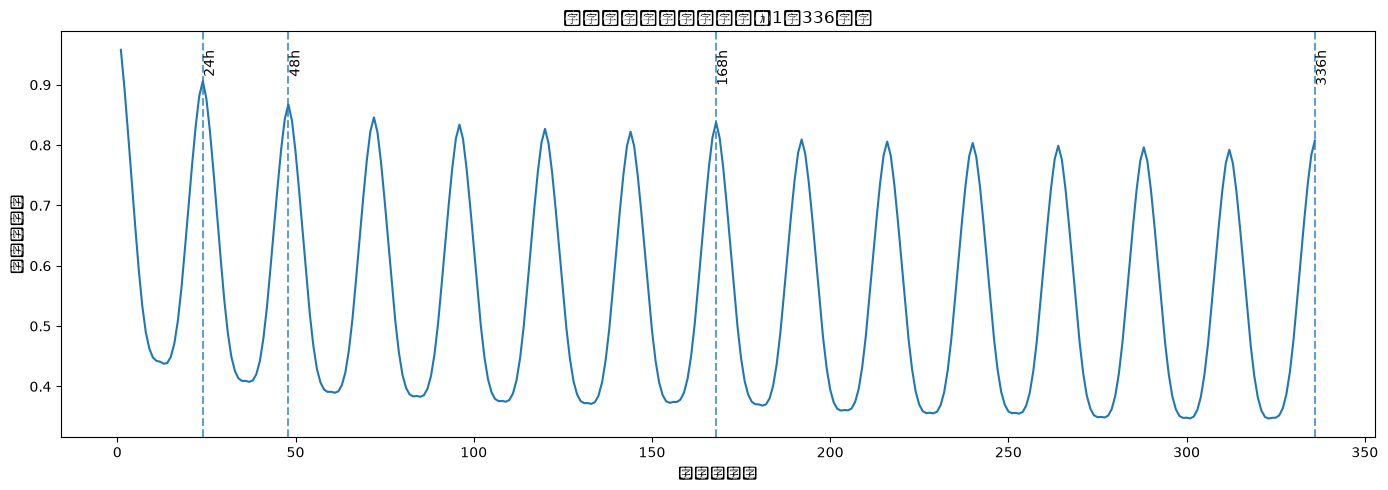


自动判断：
24小时周期很强，自相关为 0.906。
168小时周周期很强，自相关为 0.837。

已保存：
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_seasonality.csv
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_figures\seasonality_autocorrelation.png


In [5]:
# ==========================================
# 1. 检查季节性强度
# ==========================================

series = pd.to_numeric(df[TARGET_COL], errors="coerce").dropna()

lags_to_check = [1, 24, 48, 168]

autocorr_rows = []

for lag in lags_to_check:
    autocorr_value = series.autocorr(lag=lag)

    # 计算简单滞后预测误差：
    # 用 t-lag 时刻的值预测 t 时刻
    actual = series.iloc[lag:].to_numpy()
    lag_pred = series.shift(lag).iloc[lag:].to_numpy()

    mae = np.mean(np.abs(actual - lag_pred))
    rmse = np.sqrt(np.mean((actual - lag_pred) ** 2))

    autocorr_rows.append({
        "lag_hours": lag,
        "autocorrelation": autocorr_value,
        "lag_naive_MAE": mae,
        "lag_naive_RMSE": rmse
    })

seasonality_table = pd.DataFrame(autocorr_rows)

print("关键滞后自相关与简单滞后预测误差：")
display(seasonality_table.round(4))

# 绘制 1 至 336 小时自相关
max_lag = 336
acf_values = [
    series.autocorr(lag=lag)
    for lag in range(1, max_lag + 1)
]

plt.figure(figsize=(14, 5))
plt.plot(range(1, max_lag + 1), acf_values)

for lag in [24, 48, 168, 336]:
    if lag <= max_lag:
        plt.axvline(lag, linestyle="--", alpha=0.7)
        plt.text(
            lag,
            max(acf_values),
            f"{lag}h",
            rotation=90,
            verticalalignment="top"
        )

plt.xlabel("滞后小时数")
plt.ylabel("自相关系数")
plt.title("碳强度时间序列自相关：1至336小时")
plt.tight_layout()

seasonality_fig_path = FIGURES_DIR / "seasonality_autocorrelation.png"
plt.savefig(seasonality_fig_path, dpi=180)
plt.show()

# 简单判断
corr_24 = seasonality_table.loc[
    seasonality_table["lag_hours"] == 24,
    "autocorrelation"
].iloc[0]

corr_168 = seasonality_table.loc[
    seasonality_table["lag_hours"] == 168,
    "autocorrelation"
].iloc[0]

print("\n自动判断：")

if corr_24 >= 0.7:
    print(f"24小时周期很强，自相关为 {corr_24:.3f}。")
elif corr_24 >= 0.4:
    print(f"24小时周期中等，自相关为 {corr_24:.3f}。")
else:
    print(f"24小时周期较弱，自相关为 {corr_24:.3f}。")

if corr_168 >= 0.7:
    print(f"168小时周周期很强，自相关为 {corr_168:.3f}。")
elif corr_168 >= 0.4:
    print(f"168小时周周期中等，自相关为 {corr_168:.3f}。")
else:
    print(f"168小时周周期较弱，自相关为 {corr_168:.3f}。")

seasonality_table.to_csv(
    RESULTS_DIR / "diagnostic_seasonality.csv",
    index=False
)

print("\n已保存：")
print(RESULTS_DIR / "diagnostic_seasonality.csv")
print(seasonality_fig_path)

In [ ]:
# HMM状态样本量与持续时间

读取已有 HMM 状态汇总文件：


,hmm_state,carbon_mean,carbon_std,mean_duration,sample_share
0,0,516.0797,59.3448,294.8063,0.2879
1,1,541.2336,29.6864,26.2729,0.2014
2,2,549.1587,41.4211,25.1819,0.2037
3,3,561.5906,22.1606,128.7420,0.1801
4,4,609.4923,23.3498,117.1883,0.1270



HMM状态详细统计：


,hmm_state,carbon_mean,carbon_std,mean_duration,sample_share,sample_count
0,0,516.0797,59.3448,294.8063,0.2879,22501
1,1,541.2336,29.6864,26.2729,0.2014,15741
2,2,549.1587,41.4211,25.1819,0.2037,15920
3,3,561.5906,22.1606,128.7420,0.1801,14075
4,4,609.4923,23.3498,117.1883,0.1270,9931


C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:81: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:81: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:81: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:81: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:81: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:81: UserWarning: Glyph 27604 (\N{CJK UNIFIE

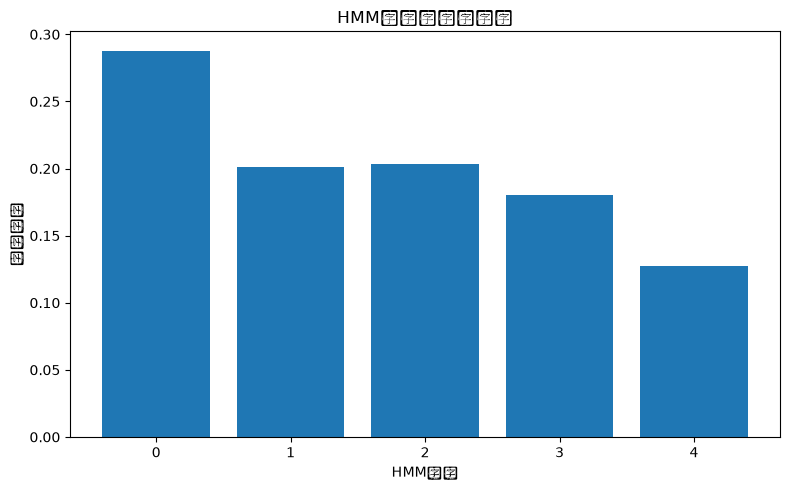

C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:98: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:98: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:98: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:98: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:98: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\3112295210.py:98: UserWarning: Glyph 32493 (\N{CJK UNIFIE

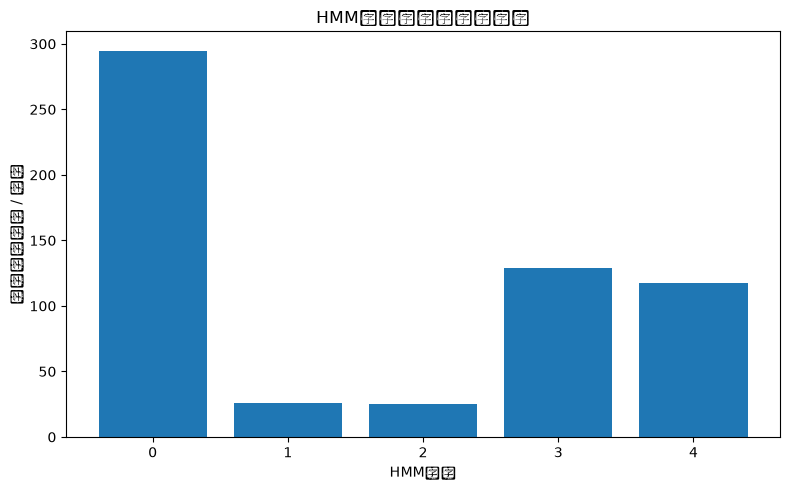


自动诊断：
状态 0：样本占比 28.79%，样本量评价：较充足
  平均持续时间为 294.81 小时，状态具有一定稳定性。
状态 1：样本占比 20.14%，样本量评价：较充足
  平均持续时间为 26.27 小时，状态具有一定稳定性。
状态 2：样本占比 20.37%，样本量评价：较充足
  平均持续时间为 25.18 小时，状态具有一定稳定性。
状态 3：样本占比 18.01%，样本量评价：一般偏少
  平均持续时间为 128.74 小时，状态具有一定稳定性。
状态 4：样本占比 12.70%，样本量评价：一般偏少
  平均持续时间为 117.19 小时，状态具有一定稳定性。

已保存：
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_hmm_state_balance.csv
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_figures\hmm_state_sample_share.png


In [6]:
# ==========================================
# 2. 检查 HMM 各状态样本量和持续时间
# ==========================================

HMM_SUMMARY_PATH = RESULTS_DIR / "hmm_state_summary.csv"

if HMM_SUMMARY_PATH.exists():
    hmm_summary = pd.read_csv(HMM_SUMMARY_PATH)
    print("读取已有 HMM 状态汇总文件：")
    display(hmm_summary.round(4))
else:
    print("未找到 hmm_state_summary.csv，将从 merged_hourly_data.csv 重新统计。")

    if "hmm_state" not in df.columns:
        raise KeyError(
            "数据中没有 hmm_state 列，且 results/hmm_state_summary.csv 不存在。"
        )

    # 重新计算状态持续时间
    state_change_group = (
        df["hmm_state"] != df["hmm_state"].shift()
    ).cumsum()

    temp = df.copy()
    temp["recomputed_state_duration"] = (
        temp.groupby(state_change_group).cumcount() + 1
    )

    hmm_summary = (
        temp.groupby("hmm_state")
        .agg(
            sample_count=("hmm_state", "size"),
            carbon_mean=(TARGET_COL, "mean"),
            carbon_std=(TARGET_COL, "std"),
            mean_duration=("recomputed_state_duration", "mean"),
            max_duration=("recomputed_state_duration", "max")
        )
        .reset_index()
    )

    hmm_summary["sample_share"] = (
        hmm_summary["sample_count"] / len(temp)
    )

# 如果原文件没有 sample_count，则补充
if "sample_count" not in hmm_summary.columns:
    if "hmm_state" not in df.columns:
        raise KeyError("完整数据中没有 hmm_state 列。")

    state_counts = (
        df["hmm_state"]
        .value_counts()
        .sort_index()
        .rename("sample_count")
        .reset_index()
        .rename(columns={"index": "hmm_state"})
    )

    hmm_summary = hmm_summary.merge(
        state_counts,
        on="hmm_state",
        how="left"
    )

# 排序
hmm_summary = hmm_summary.sort_values("hmm_state").reset_index(drop=True)

print("\nHMM状态详细统计：")
display(hmm_summary.round(4))

# 绘制样本占比
plt.figure(figsize=(8, 5))
plt.bar(
    hmm_summary["hmm_state"].astype(str),
    hmm_summary["sample_share"]
)

plt.xlabel("HMM状态")
plt.ylabel("样本占比")
plt.title("HMM各状态样本占比")
plt.tight_layout()

state_share_fig_path = FIGURES_DIR / "hmm_state_sample_share.png"
plt.savefig(state_share_fig_path, dpi=180)
plt.show()

# 绘制平均持续时间
if "mean_duration" in hmm_summary.columns:
    plt.figure(figsize=(8, 5))
    plt.bar(
        hmm_summary["hmm_state"].astype(str),
        hmm_summary["mean_duration"]
    )

    plt.xlabel("HMM状态")
    plt.ylabel("平均持续时间 / 小时")
    plt.title("HMM各状态平均持续时间")
    plt.tight_layout()

    duration_fig_path = FIGURES_DIR / "hmm_state_mean_duration.png"
    plt.savefig(duration_fig_path, dpi=180)
    plt.show()

# 自动风险判断
print("\n自动诊断：")

for _, row in hmm_summary.iterrows():
    state = int(row["hmm_state"])
    share = float(row["sample_share"])

    if share < 0.05:
        share_level = "严重不足"
    elif share < 0.10:
        share_level = "偏少"
    elif share < 0.20:
        share_level = "一般偏少"
    else:
        share_level = "较充足"

    print(
        f"状态 {state}：样本占比 {share:.2%}，"
        f"样本量评价：{share_level}"
    )

    if "mean_duration" in row and pd.notna(row["mean_duration"]):
        duration = float(row["mean_duration"])

        if duration < 2:
            print(
                f"  平均持续时间仅 {duration:.2f} 小时，"
                "状态切换非常频繁，不利于状态专家LSTM。"
            )
        elif duration < 6:
            print(
                f"  平均持续时间为 {duration:.2f} 小时，"
                "状态稳定性偏弱。"
            )
        else:
            print(
                f"  平均持续时间为 {duration:.2f} 小时，"
                "状态具有一定稳定性。"
            )

hmm_summary.to_csv(
    RESULTS_DIR / "diagnostic_hmm_state_balance.csv",
    index=False
)

print("\n已保存：")
print(RESULTS_DIR / "diagnostic_hmm_state_balance.csv")
print(state_share_fig_path)

In [ ]:
# 检验HMM状态对1、6、12、24的解释程度

高碳阈值： 593.0
不同HMM状态对应的未来目标统计：


,hmm_state,sample_count,current_carbon_mean,future_1h_mean,future_6h_mean,future_12h_mean,future_24h_mean,future_24h_high_rate
0,0,22477,516.0648,516.4121,517.2861,517.7581,517.4329,0.3233
1,1,15741,541.2336,541.4112,541.6102,541.7534,541.9961,0.2074
2,2,15920,549.1587,549.3057,549.5876,549.7190,549.2766,0.4492
3,3,14075,561.5906,561.3854,561.0119,560.8989,561.1301,0.3277
4,4,9931,609.4923,608.4714,606.2280,604.8534,605.5397,0.9753



不同状态之间的最大差异：


,future_horizon,max_minus_min
0,1h,92.0592
1,6h,88.9419
2,12h,87.0953
3,24h,88.1069
4,24h_high_event,0.7680



HMM状态解释力 eta squared：


,target,eta_squared
0,future_1h,0.3154
1,future_6h_mean,0.3319
2,future_12h_mean,0.3747
3,future_24h_mean,0.4505
4,future_24h_high_event,0.2175


C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:196: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:196: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:196: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:196: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:196: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:196: UserWarning: Glyph 26469 (\N{CJK 

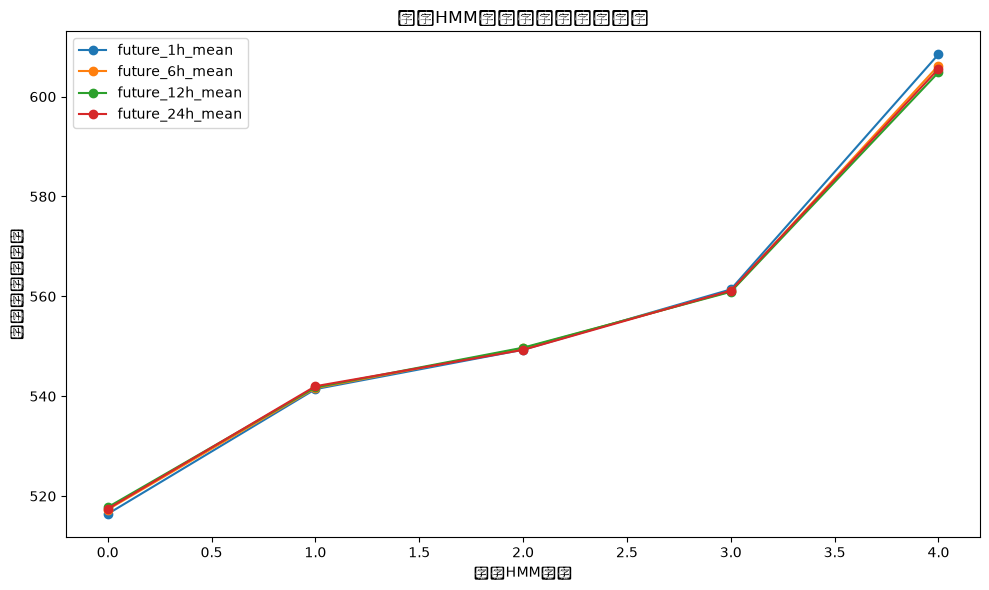

C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:215: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:215: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:215: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:215: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:215: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\1854525861.py:215: UserWarning: Glyph 26469 (\N{CJK 

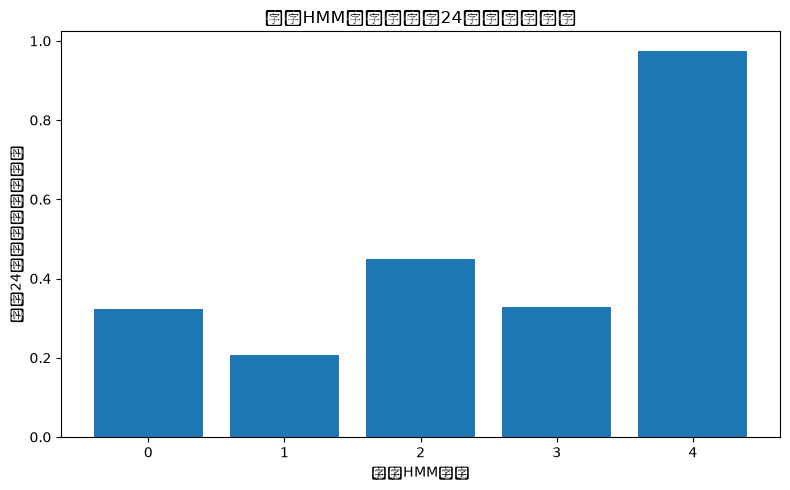


已保存：
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_hmm_future_relationship.csv
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_hmm_effect_size.csv


In [7]:
# ==========================================
# 3. 检查 HMM 状态与未来目标的关系
# ==========================================

if "hmm_state" not in df.columns:
    raise KeyError("merged_hourly_data.csv 中没有 hmm_state 列。")

# 尝试读取训练集计算出的高碳阈值
METADATA_PATH = RESULTS_DIR / "experiment_metadata.json"

high_threshold = None

if METADATA_PATH.exists():
    with open(METADATA_PATH, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    high_threshold = (
        metadata
        .get("target", {})
        .get("high_threshold")
    )

if high_threshold is None:
    # 兜底方案：
    # 这里只用于诊断，不建议用于正式论文结果
    high_threshold = df[TARGET_COL].quantile(0.80)
    print(
        "警告：没有从 experiment_metadata.json 读取到训练集阈值，"
        "暂时使用全样本80%分位数。"
    )

high_threshold = float(high_threshold)

print("高碳阈值：", high_threshold)

future_df = df[
    ["timestamp", TARGET_COL, "hmm_state"]
].copy()

# 未来第1小时
future_df["future_1h"] = future_df[TARGET_COL].shift(-1)

# 未来1至6小时均值
future_df["future_6h_mean"] = pd.concat(
    [
        future_df[TARGET_COL].shift(-h)
        for h in range(1, 7)
    ],
    axis=1
).mean(axis=1)

# 未来1至12小时均值
future_df["future_12h_mean"] = pd.concat(
    [
        future_df[TARGET_COL].shift(-h)
        for h in range(1, 13)
    ],
    axis=1
).mean(axis=1)

# 未来1至24小时均值
future_24_matrix = pd.concat(
    [
        future_df[TARGET_COL].shift(-h)
        for h in range(1, 25)
    ],
    axis=1
)

future_df["future_24h_mean"] = future_24_matrix.mean(axis=1)

# 未来24小时内是否至少出现一次高碳
future_df["future_24h_high_event"] = (
    future_24_matrix.gt(high_threshold).any(axis=1).astype(float)
)

# 最后24行没有完整未来窗口，删除
future_df = future_df.iloc[:-24].copy()

future_relation = (
    future_df.groupby("hmm_state")
    .agg(
        sample_count=("hmm_state", "size"),
        current_carbon_mean=(TARGET_COL, "mean"),
        future_1h_mean=("future_1h", "mean"),
        future_6h_mean=("future_6h_mean", "mean"),
        future_12h_mean=("future_12h_mean", "mean"),
        future_24h_mean=("future_24h_mean", "mean"),
        future_24h_high_rate=("future_24h_high_event", "mean")
    )
    .reset_index()
    .sort_values("hmm_state")
)

print("不同HMM状态对应的未来目标统计：")
display(future_relation.round(4))

# 计算状态间差异范围
difference_summary = pd.DataFrame({
    "future_horizon": [
        "1h",
        "6h",
        "12h",
        "24h",
        "24h_high_event"
    ],
    "max_minus_min": [
        future_relation["future_1h_mean"].max()
        - future_relation["future_1h_mean"].min(),

        future_relation["future_6h_mean"].max()
        - future_relation["future_6h_mean"].min(),

        future_relation["future_12h_mean"].max()
        - future_relation["future_12h_mean"].min(),

        future_relation["future_24h_mean"].max()
        - future_relation["future_24h_mean"].min(),

        future_relation["future_24h_high_rate"].max()
        - future_relation["future_24h_high_rate"].min()
    ]
})

print("\n不同状态之间的最大差异：")
display(difference_summary.round(4))

# 计算 eta squared：HMM状态对目标方差的解释比例
def eta_squared(data, group_col, value_col):
    valid = data[[group_col, value_col]].dropna()

    overall_mean = valid[value_col].mean()

    ss_between = sum(
        len(group) * (group[value_col].mean() - overall_mean) ** 2
        for _, group in valid.groupby(group_col)
    )

    ss_total = (
        (valid[value_col] - overall_mean) ** 2
    ).sum()

    if ss_total == 0:
        return np.nan

    return ss_between / ss_total


effect_rows = []

for col in [
    "future_1h",
    "future_6h_mean",
    "future_12h_mean",
    "future_24h_mean",
    "future_24h_high_event"
]:
    effect_rows.append({
        "target": col,
        "eta_squared": eta_squared(
            future_df,
            "hmm_state",
            col
        )
    })

effect_table = pd.DataFrame(effect_rows)

print("\nHMM状态解释力 eta squared：")
display(effect_table.round(4))

# 绘图：不同状态的未来均值
plot_data = future_relation.set_index("hmm_state")[
    [
        "future_1h_mean",
        "future_6h_mean",
        "future_12h_mean",
        "future_24h_mean"
    ]
]

plt.figure(figsize=(10, 6))

for column in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[column],
        marker="o",
        label=column
    )

plt.xlabel("当前HMM状态")
plt.ylabel("未来碳强度均值")
plt.title("不同HMM状态下的未来碳强度")
plt.legend()
plt.tight_layout()

future_relation_fig_path = (
    FIGURES_DIR / "hmm_state_future_relationship.png"
)

plt.savefig(future_relation_fig_path, dpi=180)
plt.show()

# 绘制未来高碳风险
plt.figure(figsize=(8, 5))
plt.bar(
    future_relation["hmm_state"].astype(str),
    future_relation["future_24h_high_rate"]
)

plt.xlabel("当前HMM状态")
plt.ylabel("未来24小时高碳事件比例")
plt.title("不同HMM状态下未来24小时高碳风险")
plt.tight_layout()

future_risk_fig_path = (
    FIGURES_DIR / "hmm_state_future_high_risk.png"
)

plt.savefig(future_risk_fig_path, dpi=180)
plt.show()

future_relation.to_csv(
    RESULTS_DIR / "diagnostic_hmm_future_relationship.csv",
    index=False
)

effect_table.to_csv(
    RESULTS_DIR / "diagnostic_hmm_effect_size.csv",
    index=False
)

print("\n已保存：")
print(RESULTS_DIR / "diagnostic_hmm_future_relationship.csv")
print(RESULTS_DIR / "diagnostic_hmm_effect_size.csv")

In [ ]:
# 可再生能源及其他输入特征质量

识别出的可再生能源相关数值列：
 - renewable_percentage
 - renewable_percentage_is_estimated
 - renewable_percentage_temporal_granularity
 - renewable_percentage_emission_factor_type
 - production_geothermal_MW
 - production_biomass_MW
 - production_wind_MW
 - production_solar_MW
 - production_hydro_MW
 - production_hydro_discharge_MW
 - consumption_geothermal_MW
 - consumption_biomass_MW
 - consumption_wind_MW
 - consumption_solar_MW
 - consumption_hydro_MW
 - consumption_hydro_discharge_MW
 - wind_share
 - solar_share
 - hydro_share
 - biomass_share

所有数值特征质量汇总：


,feature,missing_rate,zero_rate,unique_count,mean,std,min,max,dominant_value_rate,is_constant,is_near_constant,pearson_corr_with_target
5,carbon_temporal_granularity,1.0,0.0,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
7,renewable_percentage_temporal_granularity,1.0,0.0,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
8,renewable_percentage_emission_factor_type,1.0,0.0,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
10,carbon_free_percentage_temporal_granularity,1.0,0.0,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
11,carbon_free_percentage_emission_factor_type,1.0,0.0,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
78,hmm_prob_4,0.0,0.0,78167,0.1274,0.3233,0.0,1.0000,0.0000,False,False,0.4836
79,hmm_high_prob,0.0,0.0,78167,0.1274,0.3233,0.0,1.0000,0.0000,False,False,0.4836
80,hmm_transition_to_high,0.0,0.0,77737,0.1276,0.3155,0.0,0.9788,0.0050,False,False,0.4857
81,hmm_entropy,0.0,0.0,78167,0.0808,0.1694,0.0,1.0949,0.0000,False,False,0.0740



可再生能源相关特征质量：


,feature,missing_rate,zero_rate,unique_count,mean,std,min,max,dominant_value_rate,is_constant,is_near_constant,pearson_corr_with_target
7,renewable_percentage_temporal_granularity,1.0,0.0000,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
8,renewable_percentage_emission_factor_type,1.0,0.0000,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
16,production_geothermal_MW,1.0,0.0000,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
25,production_hydro_discharge_MW,1.0,0.0000,0,NaN,NaN,NaN,NaN,1.0000,True,True,NaN
28,consumption_geothermal_MW,0.0,1.0000,1,0.0000,0.0000,0.0000,0.0000,1.0000,True,True,NaN
37,consumption_hydro_discharge_MW,0.0,1.0000,1,0.0000,0.0000,0.0000,0.0000,1.0000,True,True,NaN
6,renewable_percentage,0.0,0.0000,52,28.6827,6.6487,13.0000,64.0000,0.0753,False,False,-0.9935
17,production_biomass_MW,0.0,0.0000,18902,17097.0747,5443.4700,6832.0000,28352.0000,0.0060,False,False,-0.4039
19,production_wind_MW,0.0,0.0001,59758,76033.1254,46374.5639,0.0000,453717.0000,0.0001,False,False,-0.6223
20,production_solar_MW,0.0,0.3682,41953,52824.0176,87573.0540,0.0000,656288.0000,0.3682,False,False,-0.7309



时间对齐检查：
总时间间隔数量： 78167
非1小时间隔数量： 0
时间序列严格保持1小时间隔。

疑似统一填0的特征：


...


近恒定列：


,feature,unique_count,dominant_value_rate
5,carbon_temporal_granularity,0,1.0
7,renewable_percentage_temporal_granularity,0,1.0
8,renewable_percentage_emission_factor_type,0,1.0
10,carbon_free_percentage_temporal_granularity,0,1.0
11,carbon_free_percentage_emission_factor_type,0,1.0
13,total_load_temporal_granularity,0,1.0
14,total_load_emission_factor_type,0,1.0
16,production_geothermal_MW,0,1.0
23,production_oil_MW,0,1.0
25,production_hydro_discharge_MW,0,1.0



可再生能源特征相关矩阵：


,renewable_percentage,renewable_percentage_is_estimated,renewable_percentage_temporal_granularity,renewable_percentage_emission_factor_type,production_geothermal_MW,production_biomass_MW,production_wind_MW,production_solar_MW,production_hydro_MW,production_hydro_discharge_MW,consumption_geothermal_MW,consumption_biomass_MW,consumption_wind_MW,consumption_solar_MW,consumption_hydro_MW,consumption_hydro_discharge_MW,wind_share,solar_share,hydro_share,biomass_share
renewable_percentage,1.000,NaN,NaN,NaN,NaN,0.374,0.599,0.773,0.315,NaN,NaN,0.374,0.599,0.773,0.315,NaN,0.458,0.767,-0.038,-0.014
renewable_percentage_is_estimated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
renewable_percentage_temporal_granularity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
renewable_percentage_emission_factor_type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_geothermal_MW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_biomass_MW,0.374,NaN,NaN,NaN,NaN,1.000,0.593,0.336,0.196,NaN,NaN,1.000,0.593,0.336,0.196,NaN,0.446,0.285,-0.320,0.825
production_wind_MW,0.599,NaN,NaN,NaN,NaN,0.593,1.000,0.365,-0.094,NaN,NaN,0.593,1.000,0.365,-0.094,NaN,0.944,0.333,-0.450,0.369
production_solar_MW,0.773,NaN,NaN,NaN,NaN,0.336,0.365,1.000,-0.043,NaN,NaN,0.336,0.365,1.000,-0.043,NaN,0.150,0.978,-0.417,-0.099
production_hydro_MW,0.315,NaN,NaN,NaN,NaN,0.196,-0.094,-0.043,1.000,NaN,NaN,0.196,-0.094,-0.043,1.000,NaN,-0.203,-0.102,0.803,0.011
production_hydro_discharge_MW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\len\AppData\Local\Temp\ipykernel_17576\570362937.py:205: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\570362937.py:205: UserWarning: Glyph 20877 (\N{CJK UNIFIED IDEOGRAPH-518D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\570362937.py:205: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\570362937.py:205: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\570362937.py:205: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\len\AppData\Local\Temp\ipykernel_17576\570362937.py:205: UserWarning: Glyph 29305 (\N{CJK UNIFIE

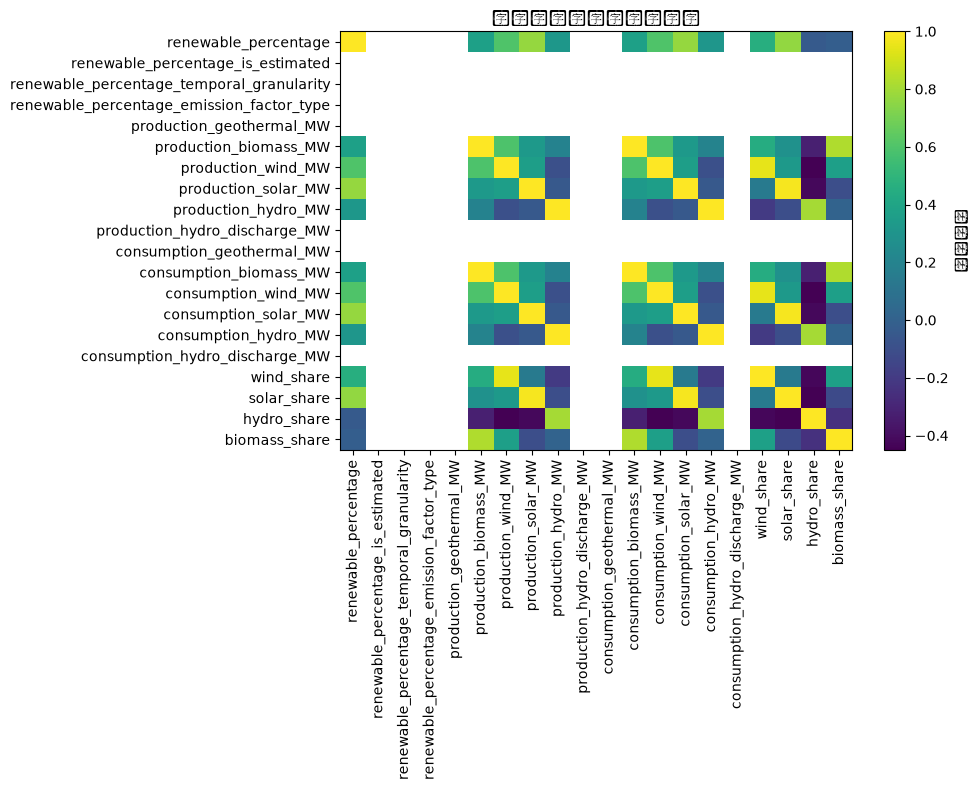


renewable_percentage 与其他可再生能源列的相关性：


,correlation
production_solar_MW,0.7731
consumption_solar_MW,0.7731
solar_share,0.7672
production_wind_MW,0.5985
consumption_wind_MW,0.5985
wind_share,0.4582
consumption_biomass_MW,0.3744
production_biomass_MW,0.3744
production_hydro_MW,0.3149
consumption_hydro_MW,0.3147


没有发现 renewable_percentage 与单一特征之间绝对相关性达到0.98以上。

自动识别的问题特征：


,feature,issue,value
0,carbon_temporal_granularity,missing_rate_above_5_percent,1.0
1,carbon_temporal_granularity,constant_feature,0.0
2,renewable_percentage_temporal_granularity,missing_rate_above_5_percent,1.0
3,renewable_percentage_temporal_granularity,constant_feature,0.0
4,renewable_percentage_emission_factor_type,missing_rate_above_5_percent,1.0
5,renewable_percentage_emission_factor_type,constant_feature,0.0
6,carbon_free_percentage_temporal_granularity,missing_rate_above_5_percent,1.0
7,carbon_free_percentage_temporal_granularity,constant_feature,0.0
8,carbon_free_percentage_emission_factor_type,missing_rate_above_5_percent,1.0
9,carbon_free_percentage_emission_factor_type,constant_feature,0.0



已保存：
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_feature_quality.csv
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_renewable_quality.csv
C:\Users\len\Desktop\算电协同\HMM-LSTM\results\diagnostic_feature_issues.csv


In [8]:
# ==========================================
# 4. 检查可再生能源特征质量
# ==========================================

# 识别可能与可再生能源有关的列
renewable_keywords = [
    "renewable",
    "solar",
    "wind",
    "hydro",
    "biomass",
    "geothermal"
]

renewable_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in renewable_keywords)
]

# 排除明显不是数值特征的字段
renewable_numeric_cols = [
    col for col in renewable_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

print("识别出的可再生能源相关数值列：")
for col in renewable_numeric_cols:
    print(" -", col)

# 也检查所有数值列
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

quality_rows = []

for col in numeric_cols:
    values = pd.to_numeric(df[col], errors="coerce")

    missing_rate = values.isna().mean()
    zero_rate = (values == 0).mean()
    unique_count = values.nunique(dropna=True)
    std_value = values.std()
    mean_value = values.mean()
    min_value = values.min()
    max_value = values.max()

    # 近恒定判断：最常见值占比
    value_counts = values.value_counts(
        normalize=True,
        dropna=False
    )

    dominant_rate = (
        value_counts.iloc[0]
        if len(value_counts) > 0
        else np.nan
    )

    quality_rows.append({
        "feature": col,
        "missing_rate": missing_rate,
        "zero_rate": zero_rate,
        "unique_count": unique_count,
        "mean": mean_value,
        "std": std_value,
        "min": min_value,
        "max": max_value,
        "dominant_value_rate": dominant_rate,
        "is_constant": unique_count <= 1,
        "is_near_constant": dominant_rate >= 0.99
    })

quality_table = pd.DataFrame(quality_rows)

# 与目标变量的相关性
corr_series = (
    df[numeric_cols]
    .corr(method="pearson")[TARGET_COL]
    .rename("pearson_corr_with_target")
)

quality_table = quality_table.merge(
    corr_series,
    left_on="feature",
    right_index=True,
    how="left"
)

quality_table = quality_table.sort_values(
    ["missing_rate", "is_near_constant"],
    ascending=[False, False]
)

print("\n所有数值特征质量汇总：")
display(quality_table.round(4))

# 仅查看可再生能源相关列
renewable_quality = quality_table[
    quality_table["feature"].isin(renewable_numeric_cols)
].copy()

print("\n可再生能源相关特征质量：")
display(renewable_quality.round(4))

# 时间连续性检查
time_diff = df["timestamp"].diff().dropna()

expected_diff = pd.Timedelta(hours=1)

irregular_intervals = time_diff[time_diff != expected_diff]

print("\n时间对齐检查：")
print("总时间间隔数量：", len(time_diff))
print("非1小时间隔数量：", len(irregular_intervals))

if len(irregular_intervals) > 0:
    print("\n异常时间间隔示例：")
    display(
        pd.DataFrame({
            "timestamp": df.loc[
                irregular_intervals.index,
                "timestamp"
            ],
            "time_difference": irregular_intervals
        }).head(20)
    )
else:
    print("时间序列严格保持1小时间隔。")

# 缺失后是否可能被统一填0
print("\n疑似统一填0的特征：")

suspected_zero_filled = quality_table[
    (quality_table["zero_rate"] > 0.50)
    & (quality_table["unique_count"] > 1)
][
    [
        "feature",
        "zero_rate",
        "missing_rate",
        "unique_count",
        "std"
    ]
]

display(suspected_zero_filled.round(4))

# 恒定和近恒定列
constant_features = quality_table[
    quality_table["is_constant"]
]

near_constant_features = quality_table[
    quality_table["is_near_constant"]
]

print("\n恒定列：")
display(
    constant_features[
        [
            "feature",
            "unique_count",
            "dominant_value_rate"
        ]
    ]
)

print("\n近恒定列：")
display(
    near_constant_features[
        [
            "feature",
            "unique_count",
            "dominant_value_rate"
        ]
    ]
)

# 可再生能源特征内部相关性
if len(renewable_numeric_cols) >= 2:
    renewable_corr = df[renewable_numeric_cols].corr()

    print("\n可再生能源特征相关矩阵：")
    display(renewable_corr.round(3))

    plt.figure(figsize=(10, 8))
    plt.imshow(
        renewable_corr,
        aspect="auto",
        interpolation="nearest"
    )

    plt.xticks(
        range(len(renewable_corr.columns)),
        renewable_corr.columns,
        rotation=90
    )

    plt.yticks(
        range(len(renewable_corr.index)),
        renewable_corr.index
    )

    plt.colorbar(label="相关系数")
    plt.title("可再生能源特征相关矩阵")
    plt.tight_layout()

    renewable_corr_fig_path = (
        FIGURES_DIR / "renewable_feature_correlation.png"
    )

    plt.savefig(renewable_corr_fig_path, dpi=180)
    plt.show()

# 检查 renewable_percentage 是否可能由其他列直接计算
if "renewable_percentage" in df.columns:
    candidate_generation_cols = [
        col for col in renewable_numeric_cols
        if col != "renewable_percentage"
    ]

    print("\nrenewable_percentage 与其他可再生能源列的相关性：")

    renewable_percentage_corr = (
        df[
            ["renewable_percentage"]
            + candidate_generation_cols
        ]
        .corr()["renewable_percentage"]
        .drop("renewable_percentage")
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False
        )
    )

    display(
        renewable_percentage_corr
        .rename("correlation")
        .to_frame()
        .round(4)
    )

    very_high_corr = renewable_percentage_corr[
        renewable_percentage_corr.abs() >= 0.98
    ]

    if len(very_high_corr) > 0:
        print(
            "警告：renewable_percentage 与以下特征相关性绝对值达到0.98以上，"
            "可能存在重复信息或近似机械计算关系："
        )
        display(very_high_corr)
    else:
        print(
            "没有发现 renewable_percentage 与单一特征之间"
            "绝对相关性达到0.98以上。"
        )

# 自动输出问题清单
issues = []

for _, row in quality_table.iterrows():
    feature = row["feature"]

    if row["missing_rate"] > 0.05:
        issues.append({
            "feature": feature,
            "issue": "missing_rate_above_5_percent",
            "value": row["missing_rate"]
        })

    if row["zero_rate"] > 0.80 and row["unique_count"] > 1:
        issues.append({
            "feature": feature,
            "issue": "zero_rate_above_80_percent",
            "value": row["zero_rate"]
        })

    if row["is_constant"]:
        issues.append({
            "feature": feature,
            "issue": "constant_feature",
            "value": row["unique_count"]
        })

    elif row["is_near_constant"]:
        issues.append({
            "feature": feature,
            "issue": "near_constant_feature",
            "value": row["dominant_value_rate"]
        })

issues_table = pd.DataFrame(issues)

print("\n自动识别的问题特征：")
display(issues_table)

quality_table.to_csv(
    RESULTS_DIR / "diagnostic_feature_quality.csv",
    index=False
)

renewable_quality.to_csv(
    RESULTS_DIR / "diagnostic_renewable_quality.csv",
    index=False
)

issues_table.to_csv(
    RESULTS_DIR / "diagnostic_feature_issues.csv",
    index=False
)

print("\n已保存：")
print(RESULTS_DIR / "diagnostic_feature_quality.csv")
print(RESULTS_DIR / "diagnostic_renewable_quality.csv")
print(RESULTS_DIR / "diagnostic_feature_issues.csv")

In [ ]:
# 诊断报告

In [9]:
# ==========================================
# 5. 汇总四项诊断结果
# ==========================================

print("=" * 60)
print("四项诊断汇总")
print("=" * 60)

# 1. 季节性
seasonality_result = pd.read_csv(
    RESULTS_DIR / "diagnostic_seasonality.csv"
)

corr_24 = seasonality_result.loc[
    seasonality_result["lag_hours"] == 24,
    "autocorrelation"
].iloc[0]

corr_168 = seasonality_result.loc[
    seasonality_result["lag_hours"] == 168,
    "autocorrelation"
].iloc[0]

print("\n1. 季节性")
print(f"24小时自相关：{corr_24:.4f}")
print(f"168小时自相关：{corr_168:.4f}")

if max(corr_24, corr_168) >= 0.7:
    print("结论：周期性很强，B1季节残差表现好具有明确数据依据。")
elif max(corr_24, corr_168) >= 0.4:
    print("结论：周期性中等，季节残差仍有合理性。")
else:
    print("结论：周期性不强，需要重新检查B1优势来源。")

# 2. 状态平衡
state_balance = pd.read_csv(
    RESULTS_DIR / "diagnostic_hmm_state_balance.csv"
)

min_share = state_balance["sample_share"].min()

print("\n2. HMM状态平衡")
print(f"最小状态样本占比：{min_share:.2%}")

if min_share < 0.05:
    print("结论：存在严重少数状态，不适合使用多个状态专属LSTM专家。")
elif min_share < 0.10:
    print("结论：部分状态样本偏少，状态专家模型风险较高。")
else:
    print("结论：各状态样本量没有出现严重失衡。")

# 3. HMM未来解释力
effect_table = pd.read_csv(
    RESULTS_DIR / "diagnostic_hmm_effect_size.csv"
)

print("\n3. HMM对未来目标的解释力")
display(effect_table.round(4))

eta_1h = effect_table.loc[
    effect_table["target"] == "future_1h",
    "eta_squared"
].iloc[0]

eta_24h = effect_table.loc[
    effect_table["target"] == "future_24h_mean",
    "eta_squared"
].iloc[0]

eta_risk = effect_table.loc[
    effect_table["target"] == "future_24h_high_event",
    "eta_squared"
].iloc[0]

if eta_1h > eta_24h * 2 and eta_1h >= 0.06:
    print(
        "结论：HMM更适合短期修正，"
        "不适合强控制整个24小时轨迹。"
    )
elif eta_24h >= 0.06:
    print(
        "结论：HMM对24小时平均目标有一定解释力，"
        "可以尝试弱门控。"
    )
else:
    print(
        "结论：HMM对24小时连续预测解释力较弱，"
        "不建议继续使用强状态混合。"
    )

if eta_risk > eta_24h:
    print(
        "补充结论：HMM对风险分类的价值高于对连续回归的价值。"
    )

# 4. 特征质量
feature_issues = pd.read_csv(
    RESULTS_DIR / "diagnostic_feature_issues.csv"
)

print("\n4. 特征质量")
print("自动识别问题数量：", len(feature_issues))

if len(feature_issues) == 0:
    print("结论：未发现明显缺失、恒定或极高零值比例问题。")
else:
    issue_counts = feature_issues["issue"].value_counts()
    display(issue_counts.rename("count").to_frame())

    print(
        "结论：应先处理问题特征，再判断复杂神经网络结构是否有效。"
    )

print("\n" + "=" * 60)
print("建议判断")
print("=" * 60)

data_problem_score = 0
model_problem_score = 0

if len(feature_issues) > 0:
    data_problem_score += 1

if min_share < 0.10:
    model_problem_score += 1

if eta_24h < 0.06:
    model_problem_score += 1

if max(corr_24, corr_168) >= 0.7:
    model_problem_score += 1

print("数据问题信号：", data_problem_score)
print("模型结构问题信号：", model_problem_score)

if data_problem_score > model_problem_score:
    print(
        "总体建议：先处理数据质量，"
        "尤其是缺失、零值、恒定列和时间对齐问题。"
    )
elif model_problem_score > data_problem_score:
    print(
        "总体建议：当前更像是模型结构问题。"
        "优先停止B9强状态混合，改为B10弱残差门控。"
    )
else:
    print(
        "总体建议：数据和模型都需要处理。"
        "先清理明显问题特征，再测试B10弱残差门控。"
    )

四项诊断汇总

1. 季节性
24小时自相关：0.9060
168小时自相关：0.8375
结论：周期性很强，B1季节残差表现好具有明确数据依据。

2. HMM状态平衡
最小状态样本占比：12.70%
结论：各状态样本量没有出现严重失衡。

3. HMM对未来目标的解释力


,target,eta_squared
0,future_1h,0.3154
1,future_6h_mean,0.3319
2,future_12h_mean,0.3747
3,future_24h_mean,0.4505
4,future_24h_high_event,0.2175


结论：HMM对24小时平均目标有一定解释力，可以尝试弱门控。

4. 特征质量
自动识别问题数量： 26


,count
issue,
constant_feature,15
missing_rate_above_5_percent,11


结论：应先处理问题特征，再判断复杂神经网络结构是否有效。

建议判断
数据问题信号： 1
模型结构问题信号： 1
总体建议：数据和模型都需要处理。先清理明显问题特征，再测试B10弱残差门控。


In [ ]:
# 趋势

In [10]:
!pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = "17-25.csv"   # 如果文件不在当前目录，改成完整路径

df = pd.read_csv(file_path, low_memory=False)

# 时间格式转换
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 按时间排序
df = df.sort_values("timestamp")

# 查看数据
df.head()


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,timestamp,zone_id,carbon_intensity_gCO2eq_per_kWh,hour,weekday,month,day_of_year,carbon_is_estimated,carbon_estimation_method,carbon_temporal_granularity,...,consumption_biomass_MW,consumption_coal_MW,consumption_wind_MW,consumption_solar_MW,consumption_hydro_MW,consumption_gas_MW,consumption_oil_MW,consumption_unknown_MW,consumption_hydro_discharge_MW,consumption_battery_discharge_MW
0,2017-01-01 00:00:00+00:00,CN,629,0,6,1,1,True,GENERAL_PURPOSE_ZONE_MODEL,NaN,...,7369,441520,37240,15137,56257,14148,0,2335,0,0
1,2017-01-01 01:00:00+00:00,CN,626,1,6,1,1,True,GENERAL_PURPOSE_ZONE_MODEL,NaN,...,7368,434042,33863,21418,54227,13899,0,2222,0,0
2,2017-01-01 02:00:00+00:00,CN,627,2,6,1,1,True,GENERAL_PURPOSE_ZONE_MODEL,NaN,...,7117,435812,28902,24540,55875,12982,0,2183,0,0
3,2017-01-01 03:00:00+00:00,CN,611,3,6,1,1,True,GENERAL_PURPOSE_ZONE_MODEL,NaN,...,6973,427705,37105,29266,55918,12546,0,2047,0,0
4,2017-01-01 04:00:00+00:00,CN,609,4,6,1,1,True,GENERAL_PURPOSE_ZONE_MODEL,NaN,...,6908,420180,34714,31838,56099,12741,0,2009,0,0


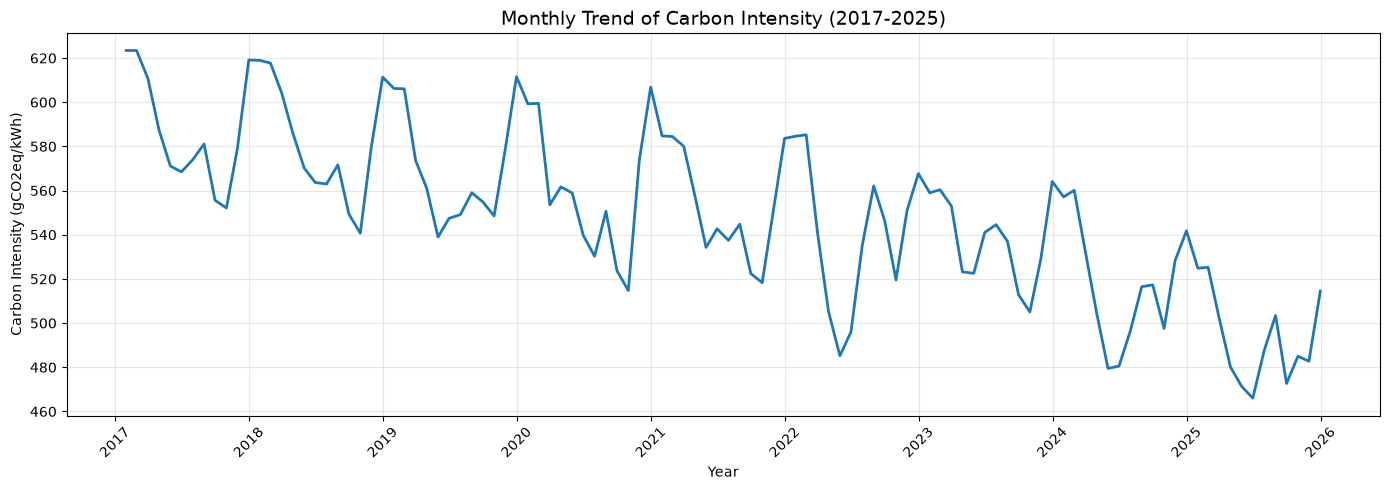

In [14]:
# 设置时间索引
df_time = df.set_index("timestamp")

# 月平均
carbon_monthly = (
    df_time["carbon_intensity_gCO2eq_per_kWh"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(
    carbon_monthly.index,
    carbon_monthly.values,
    linewidth=2
)

plt.title(
    "Monthly Trend of Carbon Intensity (2017-2025)",
    fontsize=14
)

plt.xlabel("Year")
plt.ylabel("Carbon Intensity (gCO2eq/kWh)")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

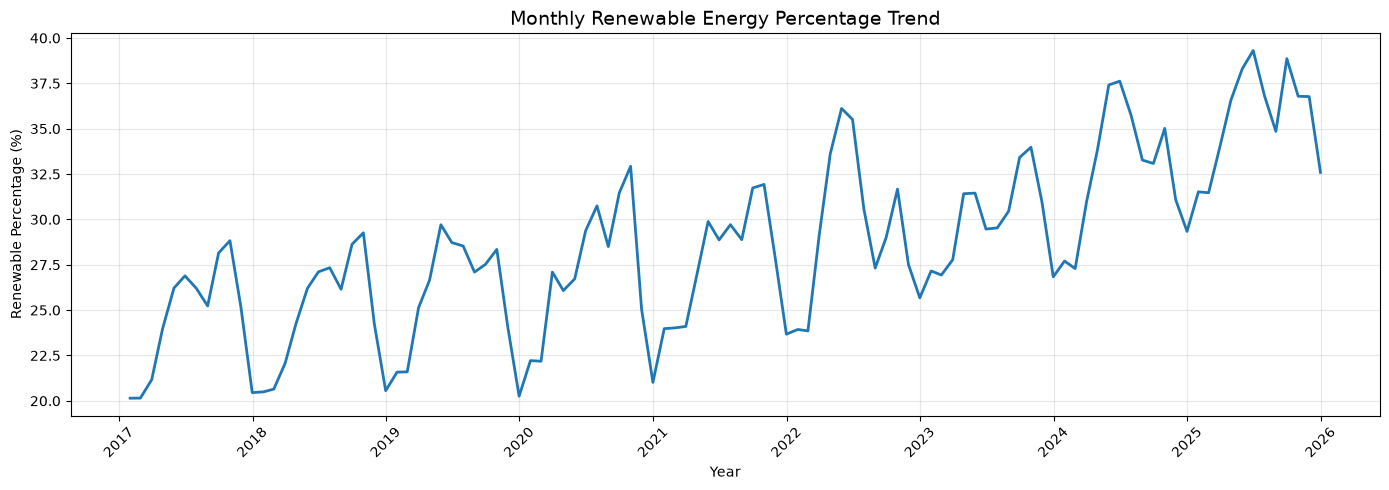

In [15]:
renew_monthly = (
    df_time["renewable_percentage"]
    .resample("ME")
    .mean()
)


plt.figure(figsize=(14,5))

plt.plot(
    renew_monthly.index,
    renew_monthly.values,
    linewidth=2
)

plt.title(
    "Monthly Renewable Energy Percentage Trend",
    fontsize=14
)

plt.xlabel("Year")
plt.ylabel("Renewable Percentage (%)")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

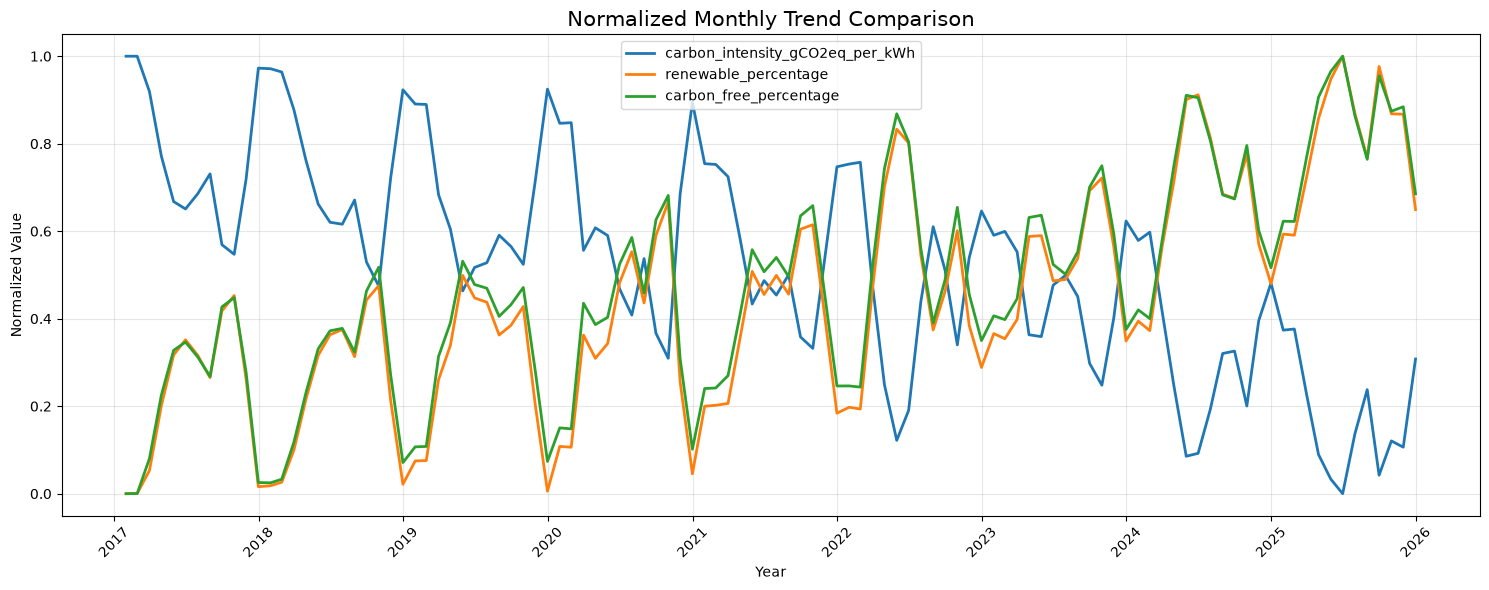

In [16]:
# 选择指标
cols = [
    "carbon_intensity_gCO2eq_per_kWh",
    "renewable_percentage",
    "carbon_free_percentage"
]


monthly = (
    df_time[cols]
    .resample("ME")
    .mean()
)


# 标准化方便比较
monthly_norm = (
    (monthly - monthly.min()) /
    (monthly.max() - monthly.min())
)


plt.figure(figsize=(15,6))

for col in monthly_norm.columns:
    plt.plot(
        monthly_norm.index,
        monthly_norm[col],
        label=col,
        linewidth=2
    )


plt.title(
    "Normalized Monthly Trend Comparison",
    fontsize=15
)

plt.xlabel("Year")

plt.ylabel("Normalized Value")

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

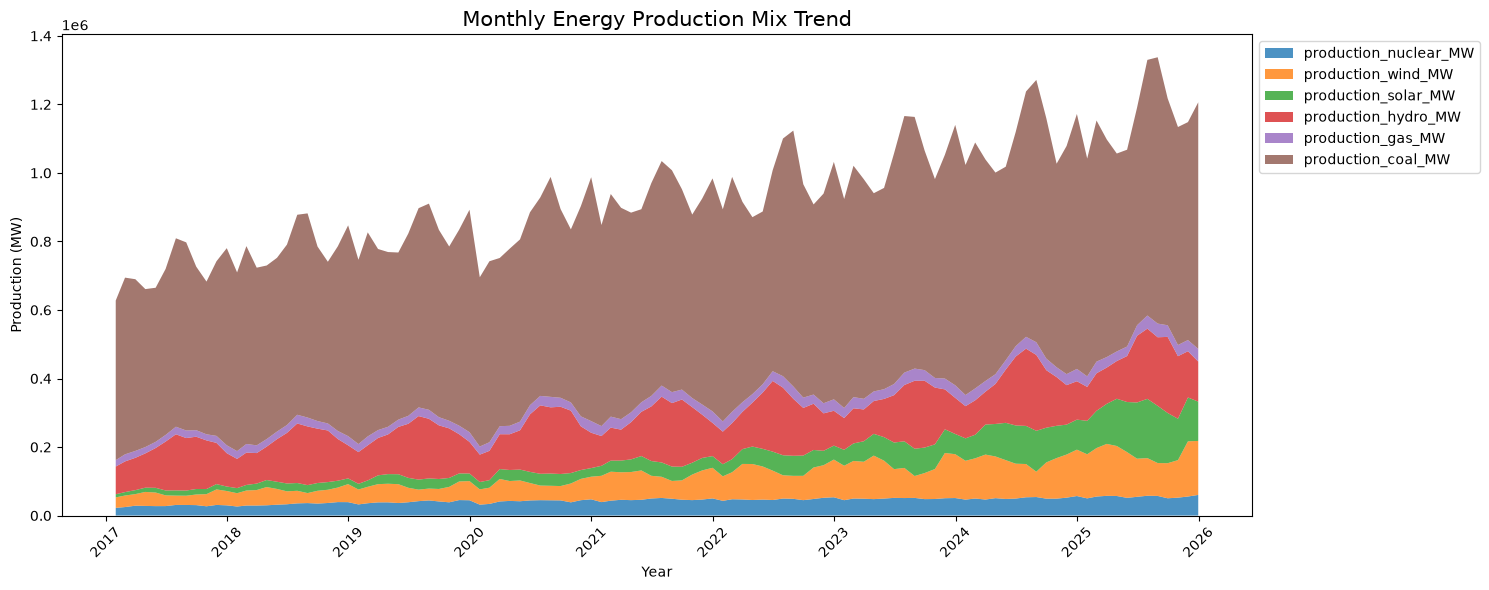

In [18]:
energy_cols = [
    "production_nuclear_MW",
    "production_wind_MW",
    "production_solar_MW",
    "production_hydro_MW",
    "production_gas_MW",
    "production_coal_MW"
]


energy_monthly = (
    df_time[energy_cols]
    .resample("ME")
    .mean()
)


plt.figure(figsize=(15,6))

plt.stackplot(
    energy_monthly.index,
    energy_monthly.T,
    labels=energy_cols,
    alpha=0.8
)


plt.title(
    "Monthly Energy Production Mix Trend",
    fontsize=15
)

plt.xlabel("Year")

plt.ylabel("Production (MW)")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1,1)
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()